
# Veridi Logistics Delivery Performance Audit

---

**Objective:** Builds a single, clean pivot dataset that powers an interactive Looker Studio dashboard auditing delivery performance , connecting logistics delays to customer sentiment, geography, and product categories.

**Pipeline Overview:**
1. Mount Google Drive & load raw CSVs
2. Join tables into a master dataset
3. Engineer all KPI columns (delays, classifications, translations)
4. Validate data quality
5. Export pivot dataset -> Google Sheets for Looker Studio
---


In [3]:
import kagglehub
olistbr_brazilian_ecommerce_path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
print('Data source import complete.')

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Data source import complete.


In [4]:
#!pip install gspread gspread-dataframe --quiet

Environment Setup

In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# google Drive & Sheets
from google.colab import drive, auth
import gspread
from gspread_dataframe import set_with_dataframe
from google.auth import default

print('Libraries loaded successfully')

Libraries loaded successfully


In [6]:
# Google Drive mount
drive.mount('/content/drive', force_remount=False)
DATA_FOLDER = '/content/drive/MyDrive/AmalitechProject/'

Mounted at /content/drive


In [7]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv


In [8]:
# Storage in drive folder
kDATA_FOLDER = '/kaggle/input/brazilian-ecommerce/'
FILES = {
    'orders'       : kDATA_FOLDER + 'olist_orders_dataset.csv',
    'reviews'      : kDATA_FOLDER + 'olist_order_reviews_dataset.csv',
    'customers'    : kDATA_FOLDER + 'olist_customers_dataset.csv',
    'products'     : kDATA_FOLDER + 'olist_products_dataset.csv',
    'order_items'  : kDATA_FOLDER + 'olist_order_items_dataset.csv',
    'sellers'      : kDATA_FOLDER + 'olist_sellers_dataset.csv',
    'geo'          : kDATA_FOLDER + 'olist_geolocation_dataset.csv',
    'translations' : kDATA_FOLDER + 'product_category_name_translation.csv',
}

Load Raw CSVs

In [9]:
orders       = pd.read_csv(FILES['orders'])
reviews      = pd.read_csv(FILES['reviews'])
customers    = pd.read_csv(FILES['customers'])
products     = pd.read_csv(FILES['products'])
order_items  = pd.read_csv(FILES['order_items'])
sellers      = pd.read_csv(FILES['sellers'])
translations = pd.read_csv(FILES['translations'])

# Parse all date columns
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print('\nTable loaded successfully:')
tables = {
    'orders': orders, 'reviews': reviews, 'customers': customers,
    'products': products, 'order_items': order_items,
    'sellers': sellers, 'translations': translations
}
for name, df in tables.items():
    print(f'   {name:<15} - {df.shape}')


Table loaded successfully:
   orders          - (99441, 8)
   reviews         - (99224, 7)
   customers       - (99441, 5)
   products        - (32951, 9)
   order_items     - (112650, 7)
   sellers         - (3095, 4)
   translations    - (71, 2)


## Schema Inspection

A fast sanity check on each table's columns and null rates before joining.

In [10]:
def null_report(df, name):
    print(name.upper())
    nulls = df.isnull().mean().mul(100).round(1)
    report = pd.DataFrame({'dtype': df.dtypes, 'null_%': nulls})
    print(report.to_string())

for name, df in tables.items():
    null_report(df, name)

ORDERS
                                        dtype  null_%
order_id                               object     0.0
customer_id                            object     0.0
order_status                           object     0.0
order_purchase_timestamp       datetime64[ns]     0.0
order_approved_at              datetime64[ns]     0.2
order_delivered_carrier_date   datetime64[ns]     1.8
order_delivered_customer_date  datetime64[ns]     3.0
order_estimated_delivery_date  datetime64[ns]     0.0
REVIEWS
                          dtype  null_%
review_id                object     0.0
order_id                 object     0.0
review_score              int64     0.0
review_comment_title     object    88.3
review_comment_message   object    58.7
review_creation_date     object     0.0
review_answer_timestamp  object     0.0
CUSTOMERS
                           dtype  null_%
customer_id               object     0.0
customer_unique_id        object     0.0
customer_zip_code_prefix   int64     0.0
custo

## Build the Master Dataset (Joins)

**Join strategy**
- Start with `orders` as the backbone (one row per order)
- `LEFT JOIN` reviews -> one review per order (handle duplicates)
- `LEFT JOIN` customers -> geography
- `LEFT JOIN` order_items -> aggregate to order level (price, freight, category)
- `LEFT JOIN` products + translations -> English category names

In [11]:
# remv dulicate reviews, keep latest review per order
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

reviews_dedup = (
    reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')
    [['order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date']]
)

print(f'Reviews before dedup : {reviews.shape[0]}')
print(f'Reviews after dedup  : {reviews_dedup.shape[0]}')
print(f'Duplicate rows removed: {reviews.shape[0] - reviews_dedup.shape[0]}')

Reviews before dedup : 99224
Reviews after dedup  : 98673
Duplicate rows removed: 551


### aggregate order items to have one order per level

In [14]:
items_with_category = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id', how='left'
)

# englishh translation
items_with_category = items_with_category.merge(
    translations.rename(columns={'product_category_name': 'product_category_name',
                                  'product_category_name_english': 'category_en'}),
    on='product_category_name', how='left'
)

# Aggregate: sum price & freight to pick most frequent category per order
items_agg = (
    items_with_category
    .groupby('order_id')
    .agg(
        total_order_value   = ('price', 'sum'),
        total_freight_value = ('freight_value', 'sum'),
        item_count          = ('order_item_id', 'count'),
        # Most frequent category in the order
        product_category_pt = ('product_category_name', lambda x: x.mode()[0] if not x.mode().empty else np.nan),
        product_category_en = ('category_en', lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    )
    .reset_index()
)

print(f'Order items aggregated: {items_agg.shape[0]:,} unique orders')
items_agg.head(4)

Order items aggregated: 98,666 unique orders


,order_id,total_order_value,total_freight_value,item_count,product_category_pt,product_category_en
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,perfumaria,perfumery


In [13]:
#  building master dataframe via sequential LEFT JOIN
master = (
    orders
    .merge(reviews_dedup,  on='order_id',   how='left')   # +review score
    .merge(customers,      on='customer_id', how='left')   # +geography
    .merge(items_agg,      on='order_id',   how='left')   # +price, category
)

print(f'Orders table rows   : {orders.shape[0]:,}')
print(f'Master dataset rows : {master.shape[0]:,}')
if master.shape[0] == orders.shape[0]:
  print('No duplicats')
  print(f'\nMaster shape: {master.shape}')
else:
   print('check for duplicate join keys!')

Orders table rows   : 99,441
Master dataset rows : 99,441
No duplicats

Master shape: (99441, 21)


## Feature Engineering

Creating all KPI columns needed for the dashboard
- **Delivery delay** (days between estimated and actual delivery)
- **Delivery classification** (On Time / Late / Super Late)
- **Time-based features** (year, month, weekday of purchase)
- **Seller state** join
- **Revenue / freight ratio**




In [15]:
# Separating delivered vs. non-delivered orders
# Non-delivered orders (canceled, unavailable) cannot have delay calculated

delivered_statuses = ['delivered']

df_delivered = master[master['order_status'].isin(delivered_statuses)].copy()
df_other     = master[~master['order_status'].isin(delivered_statuses)].copy()

status_summary = master['order_status'].value_counts().reset_index()
status_summary.columns = ['order_status', 'count']
status_summary['pct'] = (status_summary['count'] / len(master) * 100).round(1)
print('Order status breakdown:')
print(status_summary.to_string(index=False))
print(f'\n{len(df_delivered)} delivered orders will have delay metrics calculated')
print(f'{len(df_other)} non delivered orders')

Order status breakdown:
order_status  count  pct
   delivered  96478 97.0
     shipped   1107  1.1
    canceled    625  0.6
 unavailable    609  0.6
    invoiced    314  0.3
  processing    301  0.3
     created      5  0.0
    approved      2  0.0

96478 delivered orders will have delay metrics calculated
2963 non delivered orders


In [16]:
# Calculate delivery delay (days)
# Positive = del before estimate  good
# Negative = deli aft estimate  bad

df_delivered['days_difference'] = (
    df_delivered['order_estimated_delivery_date'] - df_delivered['order_delivered_customer_date']
).dt.days

# delay, how long from purchase to handoff to carrier
df_delivered['carrier_dispatch_days'] = (
    df_delivered['order_delivered_carrier_date'] - df_delivered['order_purchase_timestamp']
).dt.days

# Total fulfillment time from purchase to customer
df_delivered['fulfillment_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']
).dt.days

print('Delay statistics (delivered orders only):')
print(df_delivered['days_difference'].describe().round(2))
print(f'\nEarly deliveries  : {(df_delivered["days_difference"] > 0).sum():,}')
print(f'On-time (0 days)  : {(df_delivered["days_difference"] == 0).sum():,}')
print(f'Late deliveries   : {(df_delivered["days_difference"] < 0).sum():,}')

Delay statistics (delivered orders only):
count    96470.00
mean        10.88
std         10.18
min       -189.00
25%          6.00
50%         11.00
75%         16.00
max        146.00
Name: days_difference, dtype: float64

Early deliveries  : 87,182
On-time (0 days)  : 1,462
Late deliveries   : 7,826


In [17]:
# classify delivery performance
def classify_delivery(days):
    if pd.isna(days):
        return 'Unknown'
    elif days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

df_delivered['delivery_status'] = df_delivered['days_difference'].apply(classify_delivery)

# order with order_status as the label for non-delivered orders
df_other['days_difference']       = np.nan
df_other['carrier_dispatch_days'] = np.nan
df_other['fulfillment_days']      = np.nan
df_other['delivery_status']       = df_other['order_status'].str.replace('_', ' ').str.title()

# Recombine
master_full = pd.concat([df_delivered, df_other], ignore_index=True)

print('Delivery classification:')
print(master_full['delivery_status'].value_counts().to_string())

Delivery classification:
delivery_status
On Time        88644
Super Late      4211
Late            3615
Shipped         1107
Canceled         625
Unavailable      609
Invoiced         314
Processing       301
Unknown            8
Created            5
Approved           2


In [18]:
# exract time based features
master_full['purchase_year']    = master_full['order_purchase_timestamp'].dt.year
master_full['purchase_month']   = master_full['order_purchase_timestamp'].dt.month
master_full['purchase_month_name'] = master_full['order_purchase_timestamp'].dt.strftime('%b')  # Jan, Feb
master_full['purchase_quarter'] = master_full['order_purchase_timestamp'].dt.quarter
master_full['purchase_weekday'] = master_full['order_purchase_timestamp'].dt.day_name()
master_full['purchase_hour']    = master_full['order_purchase_timestamp'].dt.hour
master_full['purchase_date']    = master_full['order_purchase_timestamp'].dt.date  # For time-series

print(master_full[['purchase_year','purchase_month_name','purchase_weekday','purchase_hour']].head(3))

   purchase_year purchase_month_name purchase_weekday  purchase_hour
0           2017                 Oct           Monday             10
1           2018                 Jul          Tuesday             20
2           2018                 Aug        Wednesday              8


In [19]:
# adding seler state
# this will reveals inter state shipping patterns

seller_state_map = (
    order_items[['order_id', 'seller_id']]
    .merge(sellers[['seller_id', 'seller_state', 'seller_city']], on='seller_id', how='left')
    .groupby('order_id')
    .agg(seller_state=('seller_state', lambda x: x.mode()[0] if not x.mode().empty else np.nan),
         seller_city =('seller_city',  lambda x: x.mode()[0] if not x.mode().empty else np.nan))
    .reset_index()
)

master_full = master_full.merge(seller_state_map, on='order_id', how='left')

# Flag cross-state shipments (seller_state != customer_state)
master_full['is_cross_state'] = (
    master_full['seller_state'] != master_full['customer_state']
).map({True: 'Cross-State', False: 'Same State'})

print('Seller state joined')
print(master_full['is_cross_state'].value_counts().to_string())

Seller state joined
is_cross_state
Cross-State    64011
Same State     35430


In [20]:
# Freight ratio freight as % of order value)
master_full['freight_ratio_pct'] = np.where(
    master_full['total_order_value'] > 0,
    (master_full['total_freight_value'] / master_full['total_order_value'] * 100).round(2),
    np.nan
)

# segmenting review scores
master_full['review_segment'] = pd.cut(
    master_full['review_score'],
    bins=[0, 2, 3, 5],
    labels=['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)'],
    include_lowest=True
)

print('Freight ratio and review segment added')
print('\nReview segment distribution:')
print(master_full['review_segment'].value_counts().to_string())

Freight ratio and review segment added

Review segment distribution:
review_segment
Positive (4-5)    76046
Negative (1-2)    14494
Neutral (3)        8133


In [21]:
# fill null vals before export categorical cols
string_fills = {
    'product_category_en'  : 'Uncategorized',
    'product_category_pt'  : 'Uncategorized',
    'review_comment_title'  : '',
    'review_comment_message': '',
    'seller_state'          : 'Unknown',
    'seller_city'           : 'Unknown',
    'is_cross_state'        : 'Unknown',
}
for col, fill in string_fills.items():
    if col in master_full.columns:
        master_full[col] = master_full[col].fillna(fill)

print(master_full[list(string_fills.keys())].isnull().sum())

product_category_en       0
product_category_pt       0
review_comment_title      0
review_comment_message    0
seller_state              0
seller_city               0
is_cross_state            0
dtype: int64


### Exploratory Visualisations

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False
})

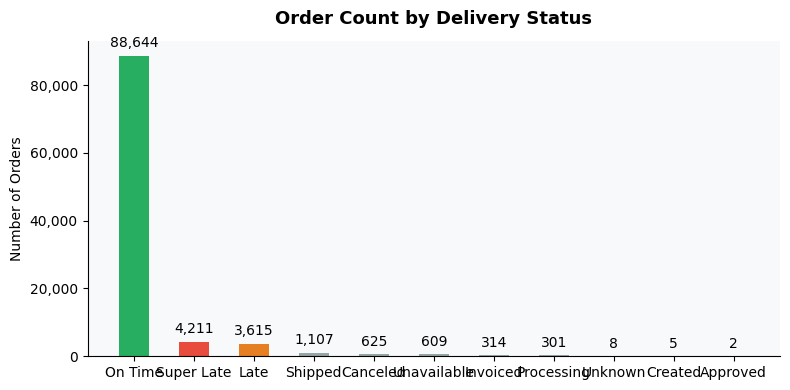

In [23]:
# Delivery Status Breakdown
status_counts = master_full['delivery_status'].value_counts()
colors = [
    '#27AE60' if s == 'On Time' else
    '#E67E22' if s == 'Late' else
    '#E74C3C' if s == 'Super Late' else '#95A5A6'
    for s in status_counts.index
]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(status_counts.index, status_counts.values, color=colors, width=0.5)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=10)
ax.set_title('Order Count by Delivery Status', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

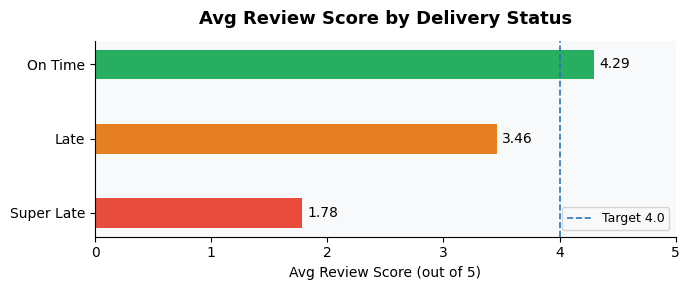

In [24]:
# Avg Review Score by Delivery Status
delivered = master_full[master_full['delivery_status'].isin(['On Time', 'Late', 'Super Late'])]
review_avg = delivered.groupby('delivery_status')['review_score'].mean().sort_values(ascending=True)
colors = [
    '#E74C3C' if s == 'Super Late' else
    '#E67E22' if s == 'Late' else '#27AE60'
    for s in review_avg.index
]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(review_avg.index, review_avg.values, color=colors, height=0.4)
ax.bar_label(bars, fmt='{:.2f}', padding=4, fontsize=10)
ax.set_xlim(0, 5)
ax.axvline(4.0, color='#2E75B6', linestyle='--', linewidth=1.2, label='Target 4.0')
ax.set_title('Avg Review Score by Delivery Status', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Avg Review Score (out of 5)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

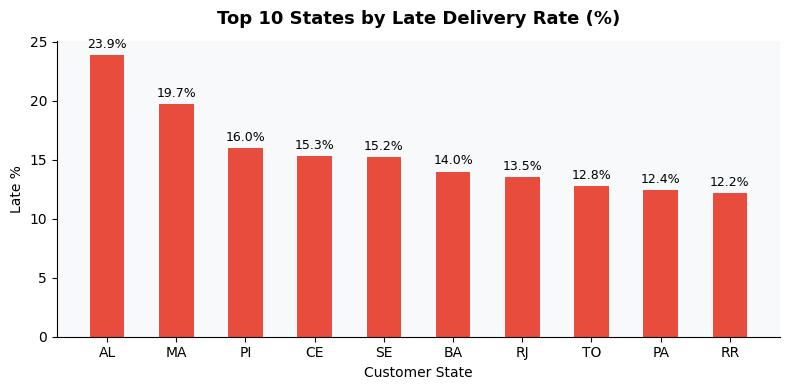

In [25]:
# Top 10 States by Late Delivery Rate
delivered_only = master_full[master_full['delivery_status'].isin(['On Time','Late','Super Late'])].copy()
delivered_only['is_late'] = delivered_only['delivery_status'].isin(['Late', 'Super Late'])
state_late = (
    delivered_only.groupby('customer_state')
    .agg(total=('order_id', 'count'), late=('is_late', 'sum'))
    .assign(late_pct=lambda x: (x['late'] / x['total'] * 100).round(1))
    .sort_values('late_pct', ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(state_late.index, state_late['late_pct'], color='#E74C3C', width=0.5)
ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=9)
ax.set_title('Top 10 States by Late Delivery Rate (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Late %')
ax.set_xlabel('Customer State')
plt.tight_layout()
plt.show()

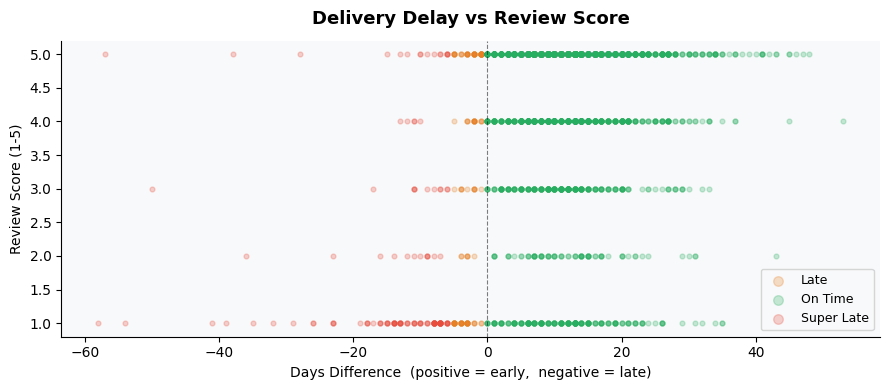

In [26]:
# Delivery Delay vs Review Score
sample = (
    master_full[master_full['delivery_status'].isin(['On Time', 'Late', 'Super Late'])]
    .dropna(subset=['days_difference', 'review_score'])
    .sample(3000, random_state=42)
)
color_map = {'On Time': '#27AE60', 'Late': '#E67E22', 'Super Late': '#E74C3C'}

fig, ax = plt.subplots(figsize=(9, 4))
for status, grp in sample.groupby('delivery_status'):
    ax.scatter(grp['days_difference'], grp['review_score'],
               alpha=0.25, s=12, color=color_map[status], label=status)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Delivery Delay vs Review Score', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Days Difference  (positive = early,  negative = late)')
ax.set_ylabel('Review Score (1-5)')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

## Section 7 — Data Quality Validation

Final checks before export: row count integrity, null audit, and range sanity checks.

In [27]:
# Validation checks

# Row count
if master_full.shape[0] == orders.shape[0]:
    print(f'\nRow count matches source orders table')
else:
    print(f'\nRow count mismatch — master has {master_full.shape[0]} but orders has {orders.shape[0]}')

# Duplicate order IDs
dup_count = master_full['order_id'].duplicated().sum()
if dup_count == 0:
    print('no duplicate order_ids')
else:
    print(f'{dup_count} duplicate order_ids found')

# Null audit on key columns
key_cols = [
    'order_id', 'customer_id', 'order_status', 'customer_state',
    'delivery_status', 'purchase_year', 'product_category_en'
]
print('\nNull check on key columns:')
for col in key_cols:
    null_pct = master_full[col].isnull().mean() * 100
    if null_pct > 10:
        print(f'{col:<35}: {null_pct:.1f}% null')
    else:
        print(f'{col:<35}: {null_pct:.1f}% null')

# Review score range
valid_reviews = master_full['review_score'].dropna()
if valid_reviews.between(1, 5).all():
    print(f'\nReview scores all within range')
else:
    bad_count = (~valid_reviews.between(1, 5)).sum()
    print(f'\n{bad_count} review scores found outside range')

# 5. Delay range sanity
delay = master_full['days_difference'].dropna()
print(f'\nDelay range: {delay.min():.0f} to {delay.max():.0f} days')
if (delay < -30).sum() > 0:
    print(f'Extreme delays upto -30 days): {(delay < -30).sum()} ')
else:
    print(f'No extreme delays')


print('Final dataset shape:', master_full.shape)


Row count matches source orders table
no duplicate order_ids

Null check on key columns:
order_id                           : 0.0% null
customer_id                        : 0.0% null
order_status                       : 0.0% null
customer_state                     : 0.0% null
delivery_status                    : 0.0% null
purchase_year                      : 0.0% null
product_category_en                : 0.0% null

Review scores all within range

Delay range: -189 to 146 days
Extreme delays upto -30 days): 360 
Final dataset shape: (99441, 37)


## Renaming Final Pivot Cols

We keep only the columns needed for the Looker Studio dashboard



In [28]:
COLUMN_MAP = {
    # IDs
    'order_id'                        : 'Order ID',
    'customer_id'                      : 'Customer ID',

    # Order metadata
    'order_status'                     : 'Order Status',
    'purchase_date'                    : 'Purchase Date',
    'purchase_year'                    : 'Purchase Year',
    'purchase_month'                   : 'Purchase Month (Num)',
    'purchase_month_name'              : 'Purchase Month',
    'purchase_quarter'                 : 'Purchase Quarter',
    'purchase_weekday'                 : 'Purchase Weekday',
    'purchase_hour'                    : 'Purchase Hour',

    # Delivery dates
    'order_purchase_timestamp'         : 'Order Purchase Datetime',
    'order_delivered_customer_date'    : 'Actual Delivery Date',
    'order_estimated_delivery_date'    : 'Estimated Delivery Date',

    # Delivery KPIs
    'days_difference'                  : 'Days Difference (Est vs Actual)',
    'delivery_status'                  : 'Delivery Status',
    'fulfillment_days'                 : 'Total Fulfillment Days',
    'carrier_dispatch_days'            : 'Carrier Dispatch Days',

    # Customer geography
    'customer_city'                    : 'Customer City',
    'customer_state'                   : 'Customer State',
    'customer_zip_code_prefix'         : 'Customer ZIP',

    # Seller geography
    'seller_state'                     : 'Seller State',
    'seller_city'                      : 'Seller City',
    'is_cross_state'                   : 'Shipment Type',

    # Product
    'product_category_pt'              : 'Product Category (PT)',
    'product_category_en'              : 'Product Category (EN)',
    'item_count'                       : 'Items in Order',

    # Financials
    'total_order_value'                : 'Order Value (BRL)',
    'total_freight_value'              : 'Freight Value (BRL)',
    'freight_ratio_pct'               : 'Freight as % of Order Value',

    # Reviews
    'review_score'                     : 'Review Score',
    'review_segment'                   : 'Review Segment',
    'review_comment_title'             : 'Review Title',
    'review_comment_message'           : 'Review Comment',
    'review_creation_date'             : 'Review Date',
}

# Filter to only columns that exist in the dataframe
existing_cols = [c for c in COLUMN_MAP.keys() if c in master_full.columns]
pivot_df = master_full[existing_cols].rename(columns=COLUMN_MAP)

print(f'Pivot dataset: {pivot_df.shape}')
print('\nColumns in final pivot dataset:')
for i, col in enumerate(pivot_df.columns, 1):
    print(f'  {i:>2}. {col}')

Pivot dataset: (99441, 34)

Columns in final pivot dataset:
   1. Order ID
   2. Customer ID
   3. Order Status
   4. Purchase Date
   5. Purchase Year
   6. Purchase Month (Num)
   7. Purchase Month
   8. Purchase Quarter
   9. Purchase Weekday
  10. Purchase Hour
  11. Order Purchase Datetime
  12. Actual Delivery Date
  13. Estimated Delivery Date
  14. Days Difference (Est vs Actual)
  15. Delivery Status
  16. Total Fulfillment Days
  17. Carrier Dispatch Days
  18. Customer City
  19. Customer State
  20. Customer ZIP
  21. Seller State
  22. Seller City
  23. Shipment Type
  24. Product Category (PT)
  25. Product Category (EN)
  26. Items in Order
  27. Order Value (BRL)
  28. Freight Value (BRL)
  29. Freight as % of Order Value
  30. Review Score
  31. Review Segment
  32. Review Title
  33. Review Comment
  34. Review Date


In [33]:
pivot_df.head(5)

,Order ID,Customer ID,Order Status,Purchase Date,Purchase Year,Purchase Month (Num),Purchase Month,Purchase Quarter,Purchase Weekday,Purchase Hour,...,Product Category (EN),Items in Order,Order Value (BRL),Freight Value (BRL),Freight as % of Order Value,Review Score,Review Segment,Review Title,Review Comment,Review Date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017,10,Oct,4,Monday,10,...,housewares,1.0,29.99,8.72,29.08,4.0,Positive (4-5),,"Não testei o produto ainda, mas ele veio corre...",2017-10-11
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018,7,Jul,3,Tuesday,20,...,perfumery,1.0,118.70,22.76,19.17,4.0,Positive (4-5),Muito boa a loja,Muito bom o produto.,2018-08-08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018,8,Aug,3,Wednesday,8,...,auto,1.0,159.90,19.22,12.02,5.0,Positive (4-5),,,2018-08-18
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017,11,Nov,4,Saturday,19,...,pet_shop,1.0,45.00,27.20,60.44,5.0,Positive (4-5),,O produto foi exatamente o que eu esperava e e...,2017-12-03
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018,2,Feb,1,Tuesday,21,...,stationery,1.0,19.90,8.72,43.82,5.0,Positive (4-5),,,2018-02-17


## Export to CSV

In [29]:
# Export as CSV folder

# Convt date/datetime columns to strings
export_df = pivot_df.copy()
for col in export_df.select_dtypes(include=['datetime64[ns]', 'datetimetz']).columns:
    export_df[col] = export_df[col].astype(str)
export_df['Purchase Date']   = export_df['Purchase Date'].astype(str)
export_df['Review Segment']  = export_df['Review Segment'].astype(str)

# Save
CSV_PATH = DATA_FOLDER + 'olist_pivot_dashboard_ready.csv'
export_df.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')

print(f'Saved to: {CSV_PATH}')

Saved to: /content/drive/MyDrive/AmalitechProject/olist_pivot_dashboard_ready.csv


In [42]:
from google.colab import auth
from google.auth import default
from googleapiclient.discovery import build
import gspread

# Authenticate
auth.authenticate_user()
creds, _ = default()
gc           = gspread.authorize(creds)
drive_service = build('drive', 'v3', credentials=creds)

FOLDER_NAME = 'AmalitechProject'

results = drive_service.files().list(
    q=f"name='{FOLDER_NAME}' and mimeType='application/vnd.google-apps.folder' and trashed=false",
    fields='files(id, name)'
).execute()

folders = results.get('files', [])

if folders:
    folder_id = folders[0]['id']
    print(f'Found folder: {FOLDER_NAME} (id: {folder_id})')
else:
    print(f'Folder "{FOLDER_NAME}" not found')

# Open or create the sheet
SHEET_NAME = 'Olist_Delivery_Audit_Pivot'

try:
    sh = gc.open(SHEET_NAME)
    print(f'Found existing sheet — overwriting')
except gspread.SpreadsheetNotFound:
    sh = gc.create(SHEET_NAME)
    print(f'Created new sheet: {SHEET_NAME}')

# Move the sheet into project folder
file = drive_service.files().get(fileId=sh.id, fields='parents').execute()
previous_parents = ','.join(file.get('parents', []))

drive_service.files().update(
    fileId     = sh.id,
    addParents = folder_id,
    removeParents = previous_parents,
    fields     = 'id, parents'
).execute()

export_df = pivot_df.copy()
for col in export_df.columns:
    export_df[col] = export_df[col].astype(str).replace('nan', '').replace('NaT', '')

worksheet = sh.sheet1
worksheet.clear()

headers = [export_df.columns.tolist()]
rows    = export_df.values.tolist()
data    = headers + rows

CHUNK_SIZE = 5000
print(f'\nWriting {len(export_df):,} rows in chunks of {CHUNK_SIZE:,}...')

for i in range(0, len(data), CHUNK_SIZE):
    chunk      = data[i : i + CHUNK_SIZE]
    start_row  = i + 1
    end_row    = start_row + len(chunk) - 1
    worksheet.update(range_name=f'A{start_row}', values=chunk)
    print(f'Rows {start_row} → {end_row} written')

print(f' https://docs.google.com/spreadsheets/d/{sh.id}')

Found folder: AmalitechProject (id: 12YtodESVd7-vkW4aEA885PRWcKSEO-av)
Found existing sheet — overwriting

Writing 99,441 rows in chunks of 5,000...
Rows 1 → 5000 written
Rows 5001 → 10000 written
Rows 10001 → 15000 written
Rows 15001 → 20000 written
Rows 20001 → 25000 written
Rows 25001 → 30000 written
Rows 30001 → 35000 written
Rows 35001 → 40000 written
Rows 40001 → 45000 written
Rows 45001 → 50000 written
Rows 50001 → 55000 written
Rows 55001 → 60000 written
Rows 60001 → 65000 written
Rows 65001 → 70000 written
Rows 70001 → 75000 written
Rows 75001 → 80000 written
Rows 80001 → 85000 written
Rows 85001 → 90000 written
Rows 90001 → 95000 written
Rows 95001 → 99442 written
 https://docs.google.com/spreadsheets/d/1dcyW6hZzV7VGyEQCVLwArE6Q9L27B0SVOM6l7Y_xUJk


## Section 10. Quick Summary Statistics

A brief look at the key metrics for cross-checking in Looker Studio dashb.

In [30]:
# KPI Summary
delivered = pivot_df[pivot_df['Delivery Status'].isin(['On Time', 'Late', 'Super Late'])]

total_orders     = len(pivot_df)
delivered_orders = len(delivered)
on_time_rate     = (delivered['Delivery Status'] == 'On Time').mean() * 100
late_rate        = (delivered['Delivery Status'] == 'Late').mean() * 100
super_late_rate  = (delivered['Delivery Status'] == 'Super Late').mean() * 100
avg_review       = delivered['Review Score'].mean()
avg_delay_days   = delivered['Days Difference (Est vs Actual)'].mean()

print('=' * 50)
print('   EXECUTIVE KPI SUMMARY')
print('=' * 50)
print(f'  Total Orders          : {total_orders:>10,}')
print(f'  Delivered Orders      : {delivered_orders:>10,}')
print(f'  On Time Rate          : {on_time_rate:>9.1f}%')
print(f'  Late Rate             : {late_rate:>9.1f}%')
print(f'  Super Late Rate       : {super_late_rate:>9.1f}%')
print(f'  Avg Review Score      : {avg_review:>10.2f} / 5.0')
print(f'  Avg Days Diff         : {avg_delay_days:>10.1f} days')

   EXECUTIVE KPI SUMMARY
  Total Orders          :     99,441
  Delivered Orders      :     96,470
  On Time Rate          :      91.9%
  Late Rate             :       3.7%
  Super Late Rate       :       4.4%
  Avg Review Score      :       4.16 / 5.0
  Avg Days Diff         :       10.9 days


In [31]:
# Avg review score by delivery status
review_by_status = (
    pivot_df
    .groupby('Delivery Status')['Review Score']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Avg Review Score', 'count': 'Orders'})
    .sort_values('Avg Review Score', ascending=False)
    .round(2)
)

print('Average Review Score by Delivery Status:')
print(review_by_status.to_string())

Average Review Score by Delivery Status:
                 Avg Review Score  Orders
Delivery Status                          
Unknown                      4.50       8
On Time                      4.29   88163
Late                         3.46    3568
Approved                     2.50       2
Created                      2.33       3
Shipped                      2.00    1032
Canceled                     1.80     605
Super Late                   1.78    4093
Invoiced                     1.63     309
Unavailable                  1.53     595
Processing                   1.26     295
